# Lab 11: Preprocesamiento de Datos para ML

**Objetivo:** Aplicar las principales técnicas de preprocesamiento de datos para preparar un dataset antes de entrenar un modelo de ML.

**Problema:** Se desea construir un modelo capaz de predecir si un pasajero sobrevivió o no al hundimiento del Titanic.

In [11]:
# pip install scikit-learn
!pip install kagglehub 

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- ------------

In [4]:
# immportar librerias

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
import kagglehub

C:\Users\tinn\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
path = kagglehub.dataset_download("yasserh/titanic-dataset")

In [7]:
print("Ruta del dataset:", path)

Ruta del dataset: C:\Users\tinn\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


In [8]:
dfTitanic = pd.read_csv(path + "/Titanic-Dataset.csv")

In [9]:
dfTitanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Parte 1. Comprensión del problema

Determinar si los pasajeros sobrevivieron al hundimiento del Titanic con base en la información obtenida.

- **Survived = 0** → No sobrevivió
- **Survived = 1** → Sobrevivió

In [10]:

dfTitanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

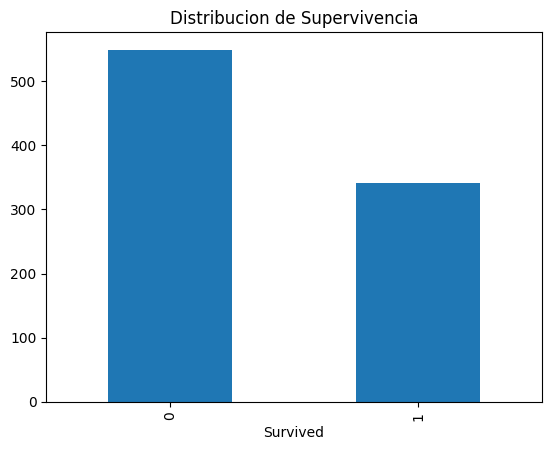

In [11]:
# graficamos
dfTitanic["Survived"].value_counts().plot(
    kind = "bar"
)
plt.title("Distribucion de Supervivencia")
plt.show()

## Parte 2. Exploración inicial

Analizamos las estadísticas descriptivas del dataset y exploramos relaciones entre variables categóricas y la supervivencia mediante agrupaciones.

In [12]:
dfTitanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
# hipotesis inicial
# por sexo
dfTitanic.groupby("Sex") ["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [14]:
# por clase
dfTitanic.groupby("Pclass") ["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [15]:
# por tarifa
dfTitanic.groupby("Fare") ["Survived"].mean()

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 248, dtype: float64

## Parte 3. Correlación e hipótesis

Creamos una matriz de correlación para identificar la relación lineal entre variables numéricas.
*Nota: La correlación lineal no identifica la importancia real de las variables en el modelo.*

In [16]:
variables_numericas = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]


In [17]:
corr = dfTitanic[variables_numericas].corr()

In [18]:
corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


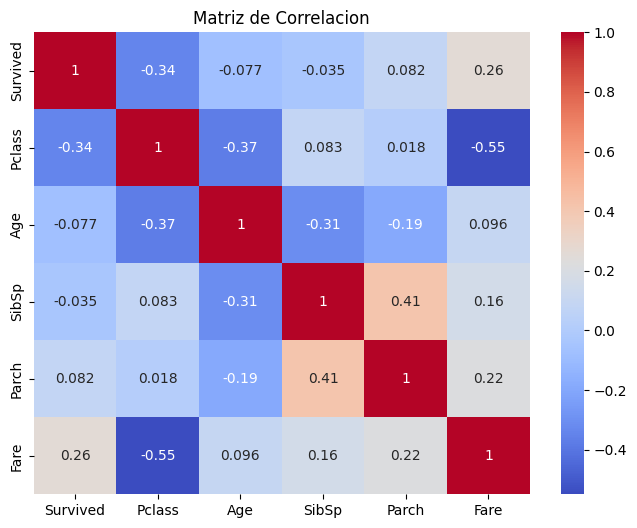

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de Correlacion")
plt.show()

## Parte 4. Selección de variables predictoras y objetivo

- **X** — Variables predictoras (características que usará el modelo)
- **Y** — Variable objetivo (lo que queremos predecir: `Survived`)

In [20]:
columnas = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

In [21]:
# definimos x y
X = dfTitanic[columnas]
Y = dfTitanic["Survived"]

In [22]:
print(X.columns.tolist())

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [23]:
print(Y.name)

Survived


## Parte 5. Tratamiento de valores faltantes

Para simplificar el proceso, realizaremos la imputación de los datos antes de la separación Train/Test.

In [24]:
X.isnull().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [25]:
X["Age"] = X["Age"].fillna(

    X["Age"].median()
    
)

C:\Users\tinn\AppData\Local\Temp\ipykernel_10000\3020770518.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Age"] = X["Age"].fillna(


In [26]:
X["Embarked"] =  X["Embarked"].fillna(
    X["Embarked"].mode()[0]
)

C:\Users\tinn\AppData\Local\Temp\ipykernel_10000\2513957187.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Embarked"] =  X["Embarked"].fillna(


In [27]:
X.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [28]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [29]:
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  891 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB


## Parte 6. Codificación de variables categóricas

Los algoritmos no entienden texto directamente. Se deben convertir las variables categóricas (Sex, Embarked) en variables numéricas mediante one-hot encoding.

In [30]:
X = pd.get_dummies(
    X,
    columns=["Sex","Embarked"],
    drop_first=True
)

In [31]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


## Parte 7. Partición de los datos

No debemos entrenar y evaluar el modelo con los mismos datos. La recomendación estándar es:

- **Entrenamiento:** 80%
- **Prueba:** 20%

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size = 0.20,
    random_state=42
)

In [47]:
print("Entrenamiento:", X_train.shape)

Entrenamiento: (712, 8)


In [48]:
print("Prueba:", y_test.shape)

Prueba: (179,)


## Parte 8. Escalado de las variables

Las variables numéricas tienen escalas distintas. El escalado (StandardScaler) evita que una variable con valores grandes domine sobre las demás.

In [49]:
columnas_numericas = [
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]

In [50]:
X_train[columnas_numericas].describe()

,Age,Fare,SibSp,Parch
count,712.0000,712.0000,712.0000,712.0000
mean,29.2041,32.5863,0.5534,0.3792
std,13.0080,51.9695,1.1764,0.7917
min,0.4200,0.0000,0.0000,0.0000
25%,22.0000,7.9250,0.0000,0.0000
50%,28.0000,14.4542,0.0000,0.0000
75%,35.0000,30.5000,1.0000,0.0000
max,80.0000,512.3292,8.0000,6.0000


In [51]:
scaler = StandardScaler() 
X_train[columnas_numericas] = scaler.fit_transform(
    X_train[columnas_numericas]
)

X_test[columnas_numericas] = scaler.transform(
    X_test[columnas_numericas]
)

In [52]:
pd.set_option('display.float_format', lambda x: '%.4f' % x)
X_train[columnas_numericas].describe()

,Age,Fare,SibSp,Parch
count,712.0000,712.0000,712.0000,712.0000
mean,0.0000,0.0000,0.0000,0.0000
std,1.0007,1.0007,1.0007,1.0007
min,-2.2144,-0.6275,-0.4707,-0.4793
25%,-0.5542,-0.4749,-0.4707,-0.4793
50%,-0.0926,-0.3491,-0.4707,-0.4793
75%,0.4459,-0.0402,0.3799,-0.4793
max,3.9077,9.2377,6.3344,7.1049


In [53]:
pd.set_option('display.float_format', lambda x: '%.4f' % x)
X_test[columnas_numericas].describe()

,Age,Fare,SibSp,Parch
count,179.0000,179.0000,179.0000,179.0000
mean,0.0603,-0.0366,-0.1286,0.0150
std,1.0065,0.7596,0.6216,1.0911
min,-2.1828,-0.6275,-0.4707,-0.4793
25%,-0.5542,-0.4754,-0.4707,-0.4793
50%,-0.0926,-0.3483,-0.4707,-0.4793
75%,0.5228,-0.0034,0.3799,-0.4793
max,3.2154,4.4247,2.9319,5.8409


## Parte 9. Entrenamiento del modelo

Usaremos un árbol de decisión para clasificar si un pasajero sobrevive o no.

In [54]:
modelo = DecisionTreeClassifier (
    max_depth = 4,
    random_state= 42
)

In [55]:
modelo.fit(
    X_train,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

## Parte 10. Evaluación del modelo

Realizamos predicciones sobre el conjunto de prueba para evaluar el rendimiento del modelo.

In [56]:
predicciones = modelo.predict(
    X_test
)

In [57]:
pd.DataFrame({
    "Real": y_test,
    "Predicción": predicciones
}).head(35)

,Real,Predicción
709,1,0
439,0,0
840,0,0
720,1,1
39,1,1
290,1,1
300,1,1
333,0,0
208,1,1
136,1,1


## Parte 11. Interpretación del accuracy

El **accuracy** mide el porcentaje de predicciones correctas realizadas por el modelo sobre el total.

| Precisión (Accuracy) | Interpretación |
|---|---|
| 50% | Adivina (aleatorio) |
| 0–70% | Aceptable / Básico |
| 70–80% | Bueno |
| 80–90% | Muy bueno |
| >90% | Excelente (posible sobreajuste) |

In [58]:
accuracy = accuracy_score(
    y_test,
    predicciones

)

In [59]:
print(f"Accuracy: {accuracy: .4f}")

Accuracy:  0.7989


## Parte 12. Importancia de las variables

Analizamos qué variables fueron más relevantes para el árbol de decisión al realizar las predicciones.

In [63]:
importancias = pd.DataFrame({
	"Variable" : X_train.columns,
	"Importancia" : modelo.feature_importances_ # que variable es importante para el modelo
})


In [65]:
importancias.sort_values(
    by = "Importancia",
    ascending = False
)

,Variable,Importancia
5,Sex_male,0.5796
0,Pclass,0.2005
4,Fare,0.0811
1,Age,0.0789
2,SibSp,0.0461
7,Embarked_S,0.0139
3,Parch,0.0000
6,Embarked_Q,0.0000
